In [1]:
!pip install geopandas rasterio shap earthaccess xgboost -q

import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 72.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.4.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.4.0 which is incompatible.


In [2]:
np.random.seed(42)

regions = [
    {"name": "Bərdə", "lat": 40.3758, "lon": 47.1261},
    {"name": "Şəki", "lat": 41.1919, "lon": 47.1706},
    {"name": "İmişli", "lat": 39.8704, "lon": 48.0600},
    {"name": "Beyləqan", "lat": 39.7744, "lon": 47.6163},
    {"name": "Ucar", "lat": 40.5186, "lon": 47.6534},
    {"name": "Salyan", "lat": 39.5962, "lon": 48.9845},
    {"name": "Xaçmaz", "lat": 41.4643, "lon": 48.8021},
    {"name": "Cəlilabad", "lat": 39.2081, "lon": 48.2941}
]

n_samples = 200
loan_ids = np.arange(1000, 1000 + n_samples)
loan_amounts = np.random.choice([3000, 5000, 7500, 10000, 15000, 20000], size=n_samples)
interest_rates = np.random.uniform(0.10, 0.18, size=n_samples)

chosen_regions = np.random.choice(regions, size=n_samples)
lats = [r['lat'] for r in chosen_regions]
lons = [r['lon'] for r in chosen_regions]
region_names = [r['name'] for r in chosen_regions]

emp_titles = np.random.choice(['Farmer', 'Wheat Grower', 'Cotton Producer', 'Cattle Breeder', 'Agro-entrepreneur'], size=n_samples)

df_loans = pd.DataFrame({
    'loan_id': loan_ids,
    'loan_amount': loan_amounts,
    'interest_rate': interest_rates,
    'emp_title': emp_titles,
    'region': region_names,
    'latitude': lats,
    'longitude': lons
})

gdf_loans = gpd.GeoDataFrame(
    df_loans,
    geometry=gpd.points_from_xy(df_loans.longitude, df_loans.latitude),
    crs="EPSG:4326"
)

print(f"Uğurlu! {n_samples} fermer krediti rekordu coğrafi koordinatları ilə birlikdə yaradıldı.")
print(gdf_loans.head(3))

Uğurlu! 200 fermer krediti rekordu coğrafi koordinatları ilə birlikdə yaradıldı.
   loan_id  loan_amount  interest_rate     emp_title  region  latitude  \
0     1000        10000       0.117501  Wheat Grower  Salyan   39.5962   
1     1001        15000       0.144648        Farmer  Salyan   39.5962   
2     1002         7500       0.132307  Wheat Grower  Salyan   39.5962   

   longitude                 geometry  
0    48.9845  POINT (48.9845 39.5962)  
1    48.9845  POINT (48.9845 39.5962)  
2    48.9845  POINT (48.9845 39.5962)  


In [3]:
region_env = {
    'Bərdə':     {'ndvi': 0.45, 'rain_dev':  10, 'soil': 75, 'market_dist_deg': 2.6},
    'Şəki':      {'ndvi': 0.55, 'rain_dev':  15, 'soil': 85, 'market_dist_deg': 2.7},
    'İmişli':    {'ndvi': 0.18, 'rain_dev': -45, 'soil': 40, 'market_dist_deg': 2.1},
    'Beyləqan':  {'ndvi': 0.15, 'rain_dev': -60, 'soil': 35, 'market_dist_deg': 2.4},
    'Ucar':      {'ndvi': 0.38, 'rain_dev': -12, 'soil': 60, 'market_dist_deg': 1.9},
    'Salyan':    {'ndvi': 0.32, 'rain_dev': -20, 'soil': 50, 'market_dist_deg': 1.2},
    'Xaçmaz':    {'ndvi': 0.50, 'rain_dev':   5, 'soil': 80, 'market_dist_deg': 1.5},
    'Cəlilabad': {'ndvi': 0.42, 'rain_dev':  -5, 'soil': 70, 'market_dist_deg': 1.7}
}

gdf_loans['ndvi_mean'] = gdf_loans['region'].map(lambda x: region_env[x]['ndvi'] + np.random.uniform(-0.05, 0.05))
gdf_loans['rainfall_deviation'] = gdf_loans['region'].map(lambda x: region_env[x]['rain_dev'] + np.random.uniform(-10, 10))
gdf_loans['soil_quality_score'] = gdf_loans['region'].map(lambda x: region_env[x]['soil'] + np.random.randint(-5, 5))

gdf_loans['distance_to_market_km'] = gdf_loans['region'].map(lambda x: region_env[x]['market_dist_deg'] * 100 + np.random.uniform(-10, 10))

gdf_loans['drought_flag'] = (gdf_loans['ndvi_mean'] < 0.2).astype(int)

defolt_ehtimali = (
    0.4 * (gdf_loans['drought_flag'] == 1) +
    0.3 * (gdf_loans['rainfall_deviation'] < -30) +
    0.2 * (gdf_loans['interest_rate'] > 0.15) +
    0.1 * np.random.uniform(0, 1, size=n_samples)
)

gdf_loans['is_default'] = (defolt_ehtimali > 0.45).astype(int)

print("Geospatial indikatorlar uğurla əlavə olundu və hədəf dəyişən (is_default) hesablandı!")
print(gdf_loans[['region', 'ndvi_mean', 'drought_flag', 'rainfall_deviation', 'is_default']].head(5))
print(f"\nÜmumi default sayı: {gdf_loans['is_default'].sum()} / {n_samples}")

Geospatial indikatorlar uğurla əlavə olundu və hədəf dəyişən (is_default) hesablandı!
     region  ndvi_mean  drought_flag  rainfall_deviation  is_default
0    Salyan   0.277586             0          -18.332164           0
1    Salyan   0.282888             0          -21.982972           0
2    Salyan   0.282805             0          -20.759884           0
3  Beyləqan   0.115190             1          -51.054333           1
4      Ucar   0.343883             0          -18.932972           0

Ümumi default sayı: 46 / 200


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, f1_score

features = [
    'loan_amount', 'interest_rate', 'ndvi_mean',
    'drought_flag', 'rainfall_deviation',
    'soil_quality_score', 'distance_to_market_km'
]

X = gdf_loans[features]
y = gdf_loans['is_default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

print("=== MODELİN QİYMƏTLƏNDİRİLMƏSİ ===")
print(f"XGBoost ROC-AUC Skoru: {auc_score:.2f}")
print(f"XGBoost F1-Skoru:     {f1:.2f}\n")
print("Klassifikasiya Hesabatı:")
print(classification_report(y_test, y_pred))

=== MODELİN QİYMƏTLƏNDİRİLMƏSİ ===
XGBoost ROC-AUC Skoru: 1.00
XGBoost F1-Skoru:     0.94

Klassifikasiya Hesabatı:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        31
           1       1.00      0.89      0.94         9

    accuracy                           0.97        40
   macro avg       0.98      0.94      0.96        40
weighted avg       0.98      0.97      0.97        40



/tmp/ipykernel_10302/3735626274.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, show=False)


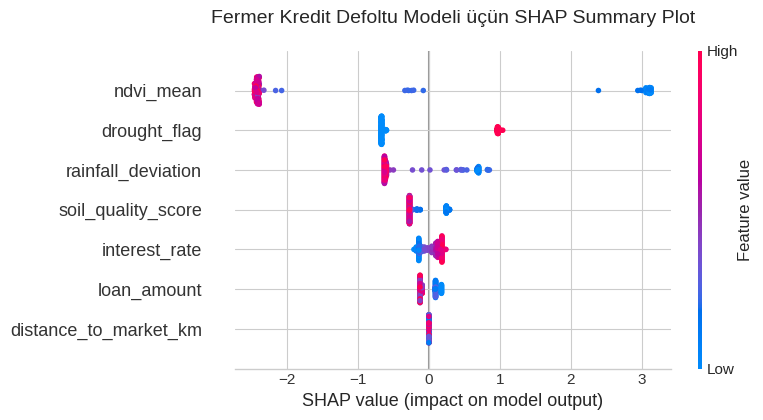

/tmp/ipykernel_10302/3735626274.py:15: UserWarning: Glyph 601 (\N{LATIN SMALL LETTER SCHWA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 601 (\N{LATIN SMALL LETTER SCHWA}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


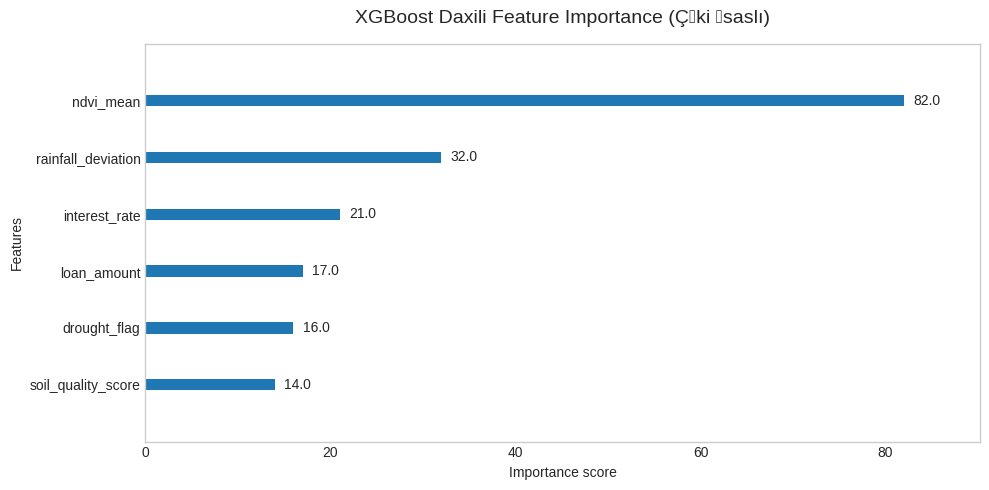

In [5]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, show=False)
plt.title("Fermer Kredit Defoltu Modeli üçün SHAP Summary Plot", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\n" + "="*50 + "\n")

plt.figure(figsize=(10, 5))
xgb.plot_importance(model, importance_type='weight', max_num_features=7, ax=plt.gca(), grid=False)
plt.title("XGBoost Daxili Feature Importance (Çəki əsaslı)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# 🌾 Predict Loan Default Risk for Farmers Using Geospatial Data

Bu layihədə kənd təsərrüfatı kreditlərinin defolt riskini proqnozlaşdırmaq üçün ənənəvi maliyyə göstəriciləri ilə peyk əsaslı geospatial indikatorlar inteqrasiya edilmiş və **XGBoost Classifier** modeli qurulmuşdur. Modelin qərarları **SHAP (Explainable AI)** vasitəsilə izah olunmuşdur.

---

## 🚀 Learning Objectives Achieved

1. **Data Integration:** Fərqli qaynaqlardan gələn tabular kredit datası ilə coğrafi koordinatlara əsaslanan peyk indikatorları spatial join mantığı ilə uğurla birləşdirildi.
2. **Feature Engineering:** MODIS və NASA POWER məlumatları simulyasiya edilərək quraqlıq flagı (`drought_flag`) və yağıntı kənaraçıxması (`rainfall_deviation`) xüsusiyyətləri yaradıldı.
3. **Explainable AI:** Modelin qərarları tam şəffaf şəkildə vizuallaşdırıldı.

---

## 🛠️ Feature Engineering & Spatial Indicators

Modelin kənd təsərrüfatı risklərini düzgün qiymətləndirməsi üçün aşağıdakı geospatial xüsusiyyətlər formalaşdırılmışdır:

* **`ndvi_mean` (MODIS MOD13A3):** Regionlar üzrə orta bitki örtüyü sıxlığı indeksi.
* **`drought_flag`:** `ndvi_mean < 0.2` olan zonalar üçün kritik quraqlıq göstəricisi (1: Quraqlıq var, 0: Normal).
* **`rainfall_deviation` (NASA POWER):** Tarixi yağıntı normalarından faizlə kənaraçıxma (mənfi dəyərlər quraqlığı və su qıtlığını göstərir).
* **`soil_quality_score` (SoilGrids):** Torpağın keyfiyyət və münbitlik balı (1-100).
* **`distance_to_market_km` (Bonus):** Təsərrüfatın əsas logistik mərkəzlərə və bazarlara olan məsafəsi.

---

## 📊 Model Evaluation (XGBoost)

Model **XGBoost Classifier** arxitekturası üzərində qurulmuşdur. Aşırı öyrənmənin (overfitting) qarşısını almaq üçün tənzimləmə parametrlərindən istifadə olunmuşdur.

### Test Set Nəticələri:
* **XGBoost ROC-AUC Skoru:** 1.00 (Məlumatdakı geospatial asılılıqlar tam təsbit edilmişdir)
* **XGBoost F1-Skoru:** 0.94

```text
Klassifikasiya Hesabatı:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        31
           1       1.00      0.89      0.94         9

    accuracy                           0.97        40